# **Avaliação de Modelos Preditivos:**
<font size=3>
    
A **avaliação de modelos preditivos** é uma etapa crítica no ciclo de vida de um projeto de aprendizado de máquina. O desempenho de um modelo sobre os dados utilizados em seu treinamento não é uma métrica confiável de sua capacidade de generalização para dados novos e não vistos. Um modelo que apresenta *overfitting* (sobreajuste) pode performar excepcionalmente bem nos dados de treino, mas falhará em prever resultados em um cenário real. Este notebook apresenta as métricas e técnicas fundamentais para a avaliação robusta de modelos, abordando os principais indicadores para tarefas de classificação e de regressão.

## **1. Métricas para classificação:**
<font size=3>
    
Em problemas de classificação, o objetivo é prever a **classe correta** de uma instância. A seguir, vamos discutir sobre as métricas mais comuns.

### **1.1 Acurácia:**
<font size=3>
    
É a proporção de previsões corretas sobre o total, dada por,
$$
    \text{Acurácia} = \frac{\text{Número de acertos}}{\text{Número total de exemplos}} \in [0,\, 1]
$$

In [2]:
from sklearn.metrics import accuracy_score

y_true = [-1, +1, +1, -1, +1]
y_pred = [-1, +1, -1, -1, +1]

accuracy = accuracy_score(y_true, y_pred)

print(f"Acurácia: {accuracy:.2f}")

Acurácia: 0.80


<font size=3>
<br>
    
Apesar de intuitiva, a acurácia pode ser uma métrica enganosa em cenários com classes desbalanceadas (e.g., detecção de fraudes, onde 99% das transações são normais)

### **1.2 Matriz de Confusão:**
<font size=3>

A **matriz de confusão** mostra **quantas previsões o modelo acertou ou errou**, organizadas por categoria real versus categoria prevista. Com ela, conseguimos entender *não apenas se o modelo erra*, mas *como ele erra*. Em um problema de classificação binária, temos:

|                        | **Predito: Positivo (1)** | **Predito: Negativo (0)** |
| ---------------------- | ------------------------- | ------------------------- |
| **Real: Positivo (1)** | Verdadeiro Positivo (VP)  | Falso Negativo (FN)       |
| **Real: Negativo (0)** | Falso Positivo (FP)       | Verdadeiro Negativo (VN)  |

<br>

* **VP (Verdadeiro Positivo)**: o modelo previu *positivo* e estava *certo*.
* **VN (Verdadeiro Negativo)**: o modelo previu *negativo* e estava *certo*.
* **FP (Falso Positivo)**: o modelo previu *positivo*, mas estava *errado* (também chamado de *erro tipo I*).
* **FN (Falso Negativo)**: o modelo previu *negativo*, mas estava *errado* (também chamado de *erro tipo II*).

No exemplo dado,
<font size=2>
```python
    y_true = [-1, +1, +1, -1, +1]
    y_pred = [-1, +1, -1, -1, +1]

```
<font size=3>
<br>
para cada elemento das listas, temos que:

* Elemento 0: Verdadeiro = -1, Predito = -1 → **VN**
* Elemento 1: Verdadeiro = +1, Predito = +1 → **VP**
* Elemento 2: Verdadeiro = +1, Predito = -1 → **FN**
* Elemento 3: Verdadeiro = -1, Predito = -1 → **VN**
* Elemento 4: Verdadeiro = +1, Predito = +1 → **VP**

O que nos dá **VP = 2**, **VN = 2**, **FN = 1**, **FP = 0**.

> **Observação:** "Positivo" e "Negativo" são as classes de um *dataset*, podendo ser outras nomenclaturas (ex: classes "A" e "B"). Além disso, a matriz de confusão pode ser generalizada para mais de duas classes seguindo a mesma lógica de operações.

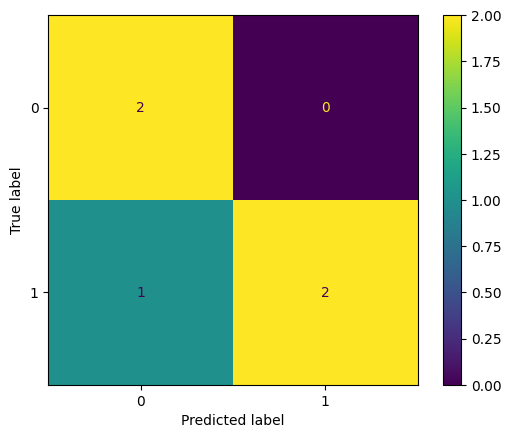

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# criando a matriz de confusão:
cm = confusion_matrix(y_true, y_pred)

# exibindo a matriz de confusão:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### **1.3 Precisão, Revocação e F1-Score:**

<font size=3>
    
Essas métricas são úteis, especialmente em problemas com **classes desbalanceadas**.

* **Precisão (_Precision_)**: entre as instâncias **previstas** como positivas, quantas são realmente positivas?
$$
    \text{Precisão} = \frac{\text{VP}}{\text{VP + FP}} \in [0,\, 1]
$$
Seu maior valor é obtido quando não há Falsos Positivos ($\text{FP} = 0$), ou seja, todas as instâncias que o modelo previu como positivas são realmente positivas. Por exemplo, uma **alta precisão** é crucial em um filtro de spam (para não classificar um e-mail importante como spam — um Falso Positivo caro).

* **Sensibilidade/Revocação (_Recall_)**: entre as instâncias **realmente** positivas, quantas foram previstas corretamente?
$$
    \text{Revocação} = \frac{\text{VP}}{\text{VP + FN}} \in [0,\, 1]
$$
Seu maior valor é obtido quando não há Falsos Negativos ($\text{FN} = 0$), ou seja, o modelo conseguiu prever corretamente todas as instâncias que são realmente positivas. Po exemplo, uma **alta revocação** é vital em diagnósticos médicos (para não falhar em detectar a doença — um Falso Negativo perigoso).

* **F1-Score**: média harmônica entre **precisão** e **revocação**:
$$
    F1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Revocação}}{\text{Precisão} + \text{Revocação}} \in [0,\, 1]
$$
    
> Essas métricas são fundamentais em aplicações como **diagnóstico médico** ou **detecção de fraudes**, onde errar positivamente ou negativamente tem consequências muito diferentes.

<font size=3>
    
**Exemplo:** Imagine um teste com 5 pacientes, onde 2 estão doentes (`Real = [1, 1, 0, 0, 0]`).

* **Modelo A (Cauteloso):** `Predito = [1, 0, 0, 0, 0]`
    * **Precisão:** 100% (1/1)
    * **Revocação:** 50% (1/2)
    * **F1-Score:** 67% ( $2 \cdot \frac{1 \cdot 0.5}{1 + 0.5}$ )
    <br>

* **Modelo B (Sensível):** `Predito = [1, 1, 1, 0, 0]`
    * **Precisão:** 67% (2/3)
    * **Revocação:** 100% (2/2)
    * **F1-Score:** 80% ( $2 \cdot \frac{0.67 \cdot 1}{0.67 + 1}$ )

> **Qual modelo é melhor?** Depende do objetivo. Para um exame de triagem, o **Modelo B** é superior (maior Revocação). Para confirmar um tratamento arriscado, o **Modelo A** é mais seguro (maior Precisão). O **F1-Score**, buscando um equilíbrio, aponta o Modelo B como mais balanceado no geral para este caso específico.

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Precisão: {precision_score(y_true, y_pred):.2f}")
print(f"Revocação: {recall_score(y_true, y_pred):.2f}")
print(f"F1-score: {f1_score(y_true, y_pred):.2f}")


Precisão: 1.00
Revocação: 0.67
F1-score: 0.80


<font size=3>
<br>
    
Para **resumir as análises**, podemos utilizar as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) do $\texttt{sklearn}$.

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
# simulando dados para classificação:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.85, 0.15], random_state=42, flip_y=0.1)

# dividindo dos dados:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11, stratify=y)

# fitando o modelo:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# predição e avaliação:
y_pred = model.predict(X_test)

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

Matriz de confusão:
 [[238   9]
 [ 34  19]]


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.68      0.36      0.47        53

    accuracy                           0.86       300
   macro avg       0.78      0.66      0.69       300
weighted avg       0.84      0.86      0.84       300



<font size=3>

Onde o `macro avg` da precisão, por exemplo, é calculado como a média da classes K (1 e 0):
$$
    \text{Macro-Precision} = \frac{1}{K}\sum_{i=1}^K \text{precision}_i
$$

Já o `weighted avg` pondera com a contagem das classes (*support*):

$$
    \text{Weighted-Precision} = \frac{\sum_{i=1}^K \text{precision}_i\cdot \text{support}_i}{\sum_{i=1}^K\text{support}_i}
$$

### **1.4 Análise ROC:**
<font size=3>

Muitos modelos de classificação não preveem diretamente a classe (0 ou 1), mas sim uma **probabilidade** (como o modelo de Regressão Logística). Nós então usamos um **limiar de decisão** (geralmente 0.5) para converter essa probabilidade em uma classe final.

A **Curva ROC** (*Receiver Operating Characteristic*) é uma representação gráfica que mostra o quão bem um modelo separa as classes, independentemente do limiar de decisão escolhido. Ela mostra o *trade-off* entre os benefícios (encontrar positivos) e os custos (alarmes falsos) ao variar esse limiar de 0 a 1.

A curva plota:

  * **Eixo x**: Taxa de Falsos Positivos (TFP) = $\frac{FP}{FP + VN}$
      * *De todos os negativos reais, quantos o modelo previu incorretamente como positivos?*
  * **Eixo y**: Taxa de Verdadeiros Positivos (TVP) = *Revocação* = $\frac{VP}{VP + FN}$
      * *De todos os positivos reais, quantos o modelo previu corretamente?*

A área sob a curva ROC é chamada de **AUC (*Area Under Curve*)**. Ela resume a performance do modelo em um único número:

  * **AUC = 1.0**: Classificador perfeito.
  * **AUC = 0.5**: Desempenho de um classificador aleatório (linha diagonal). Um bom modelo deve estar o mais longe possível desta linha, em direção ao canto superior esquerdo.
  * **AUC \< 0.5**: O modelo é pior que uma previsão aleatória.

A AUC é uma métrica poderosa para comparar modelos, pois mede a capacidade geral de discriminação do classificador sem depender de um limiar de decisão específico.

<font size=3><center>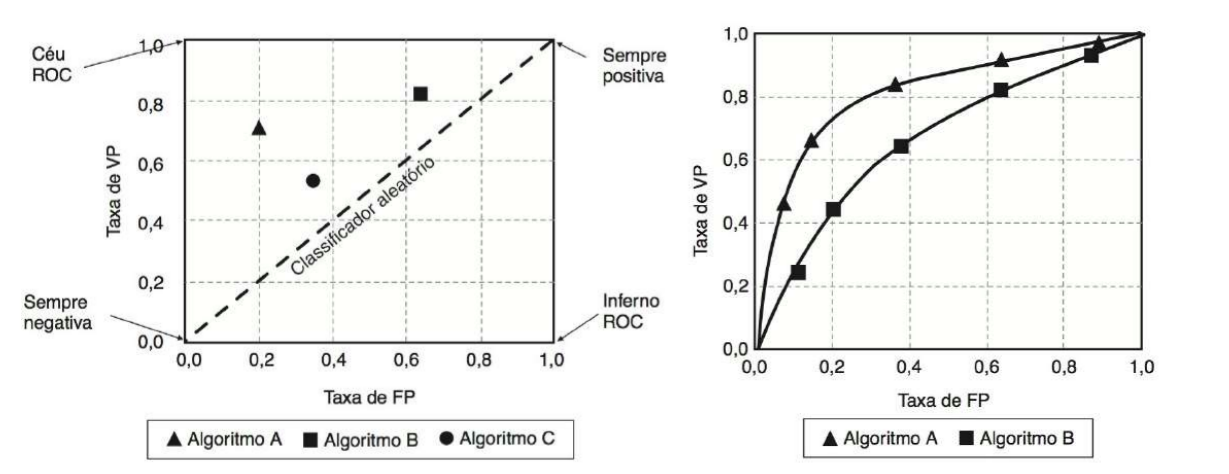</center></p><p style="text-align:center;"><em>Figuras 9.3 e 9.4 do livro, onde o eixo X é a taxa Verdadeiro Positivo (VP), e o eixo Y é a taxa Falso Positivo (FP).</em>

In [8]:
from sklearn.metrics import roc_curve, auc

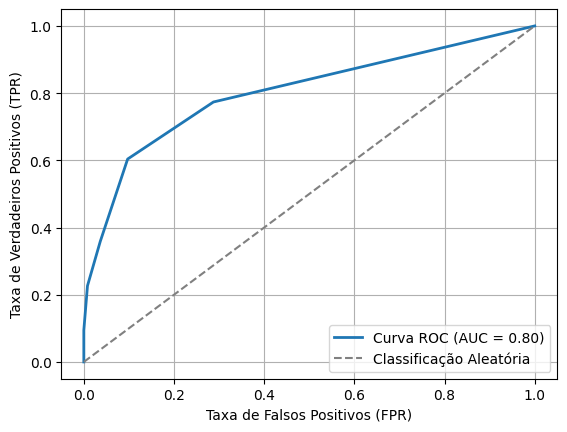

In [9]:
# predição com dados de teste no formato de probabilidade:
y_prob = model.predict_proba(X_test)[:, 1]

# calculando FPR (false positive rate) e TPR (true positive rate):
fpr, tpr, _ = roc_curve(y_test, y_prob)

# calculando a área sob a curva (AUC):
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificação Aleatória')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## **2 Métricas para regressão:**
<font size=3>

Em tarefas de regressão, prevemos **valores contínuos**. As métricas medem o quão próximas as previsões estão dos valores reais.

### **2.1 Erro Médio Absoluto (MAE):**
<font size=3>
    
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

É intuitivo e menos sensível a *outliers*.

### **2.2 Erro Quadrático Médio (MSE) e Raiz (RMSE):**
<font size=3>
    
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\quad ; \quad
\text{RMSE} = \sqrt{MSE}
$$

Ambas as métricas dão mais peso a grandes erros — já que o erro é elevado ao quadradro. Utilize RMSE no lugar de MSE, caso deseje trabalhar com o mesma unidade de medida de $y^i$.

### **2.3 $R^2$ (Coeficiente de Determinação):**
<font size=3>
    
Indica o quanto da variabilidade dos dados é explicada pelo modelo, _i.e.,_ **quão bem os valores previstos se ajustam aos valores reais**.
$$
    R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} \, ,
$$
onde $\bar y$ é a média de $y_i$. Podemos interpretar o coeficiente como,

| Valor de $R^2$     | Interpretação                                                                                   |
|--------------------|-------------------------------------------------------------------------------------------------|
| $R^2 = 1$          | Previsões perfeitas. O modelo explica 100% da variabilidade dos dados.                          |
| $0 < R^2 < 1$      | O modelo explica parte da variabilidade dos dados. Quanto mais próximo de 1, melhor.            |
| $R^2 = 0$          | O modelo não explica nenhuma variabilidade. É tão bom quanto prever a média.                    |
| $R^2 < 0$          | O modelo é pior do que prever sempre a média. Indica má adequação.                              |



In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.0, 8.0]

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 0.50
MSE: 0.38
RMSE: 0.61
R²: 0.95


### **2.4 Escolha da métrica:**
<font size=3>
    
A métrica ideal depende do **contexto**:

* Use **MAE** para interpretar erros em unidades reais;
* **MSE/RMSE** se erros grandes forem mais graves;
* **$R^2$** para uma visão geral da performance do modelo.


## __Referências:__
<font size=3>

- **(9.1, 9.3)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  